# Imports and Data Loading

In [754]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [755]:
exercise1data = np.loadtxt("../data/exercise1.csv", delimiter=',', comments='#', unpack=True, skiprows=2) # retrieve from csv.
propTime = exercise1data[1] * 10 ** -6 # convert to seconds
LCnum = exercise1data[2]
propTimeError = exercise1data[4]

L0, L0_err = 1.5e-3, 1.5e-4
H0, L0_err = 0.01e-6, 0.3e-9

# Model Functions
This is the derivation of the function being curve fit.

$$\nu^2=\frac{1}{L_0C_0} \implies \frac{1}{\nu} = \sqrt{L_0C_0} \implies numunits \cdot \sqrt{L_0C_0} = \frac{numunits}{\nu} = proptime$$

In [756]:
def LC_to_prop_time(num_units, LC):
    return (LC) ** (0.5) * num_units

In [757]:
# function for calculating chi squared reduced.
def chi_squared_reduced(y_measure, y_predict, errors, number_of_parameters):
    """Calculates the reduced chi squared of data, prediction and errors."""
    return (np.sum(((y_measure - y_predict) ** 2 )/ (errors ** 2)))/(y_measure.size - number_of_parameters)


# Curve Fit and Model Parameters

In [758]:
# curve fit of LC using curve_fit
popt, pcov = curve_fit(LC_to_prop_time, xdata=LCnum, ydata=propTime, absolute_sigma=True, sigma = propTimeError)
pstd = np.sqrt(np.diag(pcov))

cutoff = 13
# curve fit with cutoff
popt2, pcov2 = curve_fit(LC_to_prop_time, xdata=LCnum[:cutoff], ydata=propTime[:cutoff], absolute_sigma=True, sigma = propTimeError[:cutoff])
pstd2 = np.sqrt(np.diag(pcov))
print(pstd)
print(pstd2)

[4.44994763e-16]
[4.44994763e-16]


/var/folders/b4/87nbcb5j6d772d537gj3mnc80000gn/T/ipykernel_21802/1465343281.py:2: RuntimeWarning: invalid value encountered in scalar power
  return (LC) ** (0.5) * num_units


In [759]:
print("chi squared reduced =",chi_squared_reduced(propTime, LC_to_prop_time(LCnum, popt[0]), propTimeError, len(popt)))
print("chi squared reduced cutoff =",chi_squared_reduced(propTime[:cutoff], LC_to_prop_time(LCnum[:cutoff], popt2[0]), propTimeError[:cutoff], len(popt)))

print(f"Value of L_0C_0 without cutoff: {popt[0]}, \nValue of L_0C_0 with cutoff: {popt2[0]}")
pvar = np.diag(pcov)
pvar2 = np.diag(pcov2)
print(f"Uncertainty in L_0C_0 without cutoff: {np.sqrt(pvar[0])}, \nUncertainty in L_0C_0 with cutoff: {np.sqrt(pvar2[0])}")

chi squared reduced = 634935.940256552
chi squared reduced cutoff = 49664.89290715157
Value of L_0C_0 without cutoff: 1.0450399730288835e-11, 
Value of L_0C_0 with cutoff: 1.1142698260800286e-11
Uncertainty in L_0C_0 without cutoff: 4.449947625278378e-16, 
Uncertainty in L_0C_0 with cutoff: 5.12970760066574e-16


# Graphs for Curve Fit

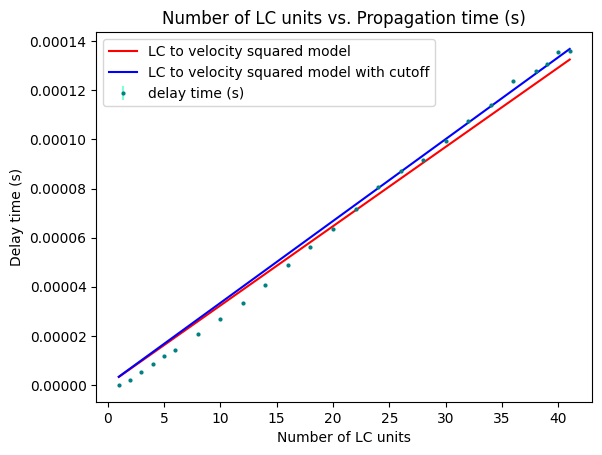

In [760]:
plt.errorbar(x = LCnum, y = propTime, yerr=propTimeError, fmt= 'o',
            ms=2, color='teal', ecolor='aquamarine', label="delay time (s)")

# plt.plot(LCnum, LC_velocity(LCnum, LCnum, 0.00002, -0.00002), label = "model_name", color='red')
# plt.plot(LCnum, LC_velocity(LCnum, popt[0], popt[1], popt[2]), label = "model_name", color='red')
plt.plot(LCnum, LC_to_prop_time(LCnum, popt[0]), label = "LC to velocity squared model", color='red')
plt.plot(LCnum, LC_to_prop_time(LCnum, popt2[0]), label = "LC to velocity squared model with cutoff", color='blue')

# Legend and titles
plt.legend()
plt.xlabel("Number of LC units")
plt.ylabel("Delay time (s)")
plt.title("Number of LC units vs. Propagation time (s)")

plt.show()

# linear relationship
# curve fit to line

Note: The error bars are too small to see.
This plot describes the delay time of pulses (s) in comparison the amount of LC units used in the 41 units transmission line. Both plots are fitted with the same equation. This equation is $proptime = numunits \cdot \sqrt{L_0C_0}$. The data was obtained by using Keysight DSOX1202G Digital Storage Oscilloscope and Keysight EDU33211A Waveform Generator. This data is stored in `exercise1.csv`. The lower half of the data was not included for the cutoff curve fit because if there is a constant delay, say in the instruments or other wires, it will be proportially less in the later values.

Neither of the models are particularly good fits:

No cutoff: $\chi^2_r = 634935$    
Cutoff: $\chi^2_r = 49664$

The LC constants for each of these fits are:

No cutoff: $L_0C_0 = 1.05 \cdot 10^{-11} \pm 4 \cdot 10^{-16} s^2$   
Cutoff: $L_0C_0 = 1.11 \cdot 10^{-11} \pm 5 \cdot 10^{-16} s^2$

<!-- chi squared reduced = 634935.940256552
chi squared reduced cutoff = 49664.89290715157
Value of L_0C_0 without cutoff: 1.0450399730288835e-11, 
Value of L_0C_0 with cutoff: 1.1142698260800286e-11
Uncertainty in L_0C_0 without cutoff: 4.449947625278378e-16, 
Uncertainty in L_0C_0 with cutoff: 5.12970760066574e-16 -->

# Graphs for Residuals

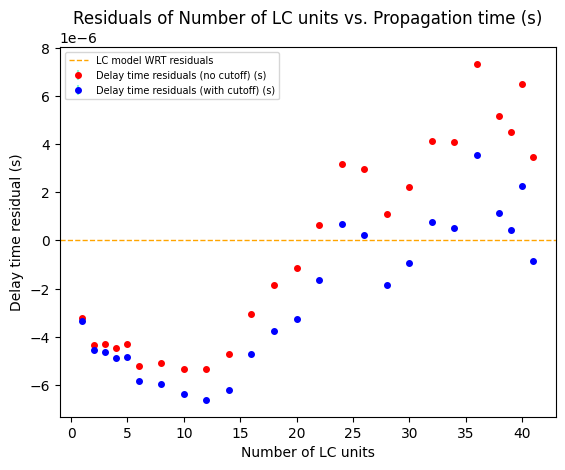

In [761]:
residuals = propTime - LC_to_prop_time(LCnum, popt[0])
residuals2  = propTime - LC_to_prop_time(LCnum, popt2[0]) # with cutoff

plt.errorbar(x = LCnum, y = residuals, yerr = propTimeError, fmt= 'o', ms=4, label="Delay time residuals (no cutoff) (s)",ls='', color='red', ecolor='aquamarine')
plt.errorbar(x = LCnum, y = residuals2, yerr = propTimeError, fmt= 'o', ms=4, label="Delay time residuals (with cutoff) (s)",ls='', color='blue', ecolor='aquamarine')
plt.axhline(y=0, color='orange', linestyle='--', linewidth=1, label="LC model WRT residuals") 

# legend and titles
plt.legend()
plt.xlabel("Number of LC units")
plt.ylabel("Delay time residual (s)")
plt.title("Residuals of Number of LC units vs. Propagation time (s)")
plt.legend(fontsize=7)
plt.show()

Note: The error bars are too small to see.
This plot describes the residuals delay time of pulses (s) in comparison the amount of LC units used in the 41 units transmission line. These residuals are in comparison to the equation $proptime = numunits \cdot \sqrt{L_0C_0}$.  The data was obtained by using Keysight DSOX1202G Digital Storage Oscilloscope and Keysight EDU33211A Waveform Generator. This data is stored in `exercise1.csv`. The lower half of the data was not included for the cutoff curve fit because if there is a constant delay, say in the instruments or other wires, it will be proportially less in the later values.

Neither of the models are particularly good fits:

No cutoff: $\chi^2_r = 634935$    
Cutoff: $\chi^2_r = 49664$

The LC constants for each of these fits are:

No cutoff: $L_0C_0 = 1.05 \cdot 10^{-11} \pm 4 \cdot 10^{-16} s^2$   
Cutoff: $L_0C_0 = 1.11 \cdot 10^{-11} \pm 5 \cdot 10^{-16} s^2$